# 1.3 金融市场基础

> **这一节讲什么？**  
> 写策略之前，你得先搞清楚：**你在什么市场里交易？买的是什么？怎么下单？交易需要付多少手续费？**
> 这些「市场规则」听起来无聊，但会直接影响你的策略能不能跑通。

## 学习目标
- 了解主要金融资产类别：股票、ETF、期货、期权
- 理解 K 线图的读法
- 熟悉订单类型：市价单 vs 限价单
- 理解交易成本对策略收益的侵蚀

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches



In [3]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）

plt.rcParams['font.sans-serif'] = ['SimHei']
# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 主要资产类别

金融市场里有各种「标的」可以交易。对初学者来说，最常接触的是股票和 ETF；更进阶的是期货和期权。

**先知道有哪些选择，以及它们的核心差别：**

| 资产 | 通俗理解 | 特点 | 示例 |
|------|---------|------|------|
| **股票 (Stock)** | 买了公司的一小块所有权 | 高风险高收益，日内可多次交易 | AAPL（苹果）, 贵州茅台 |
| **ETF** | 一篮子股票打包成一只基金 | 分散化、低费率，比买单只股票风险低 | SPY（标普500）, 510050 |
| **期货 (Futures)** | 约定以某价格在未来某天买/卖东西 | 有杠杆（风险倍增）、有到期日、可做空 | ES（标普500期货）, IF |
| **期权 (Options)** | 花少量钱买一个「选择权」，但不是义务 | 收益不对称（最多亏权利金），灵活对冲 | SPY Put（看跌期权）|
| **债券 (Bonds)** | 借给政府/公司钱，收固定利息 | 风险低，收益稳定，与股票相关性低 | 国债, TLT |
| **外汇 (FX)** | 两种货币之间互换 | 24小时交易、流动性极高 | EUR/USD（欧元兑美元）|
| **加密货币** | 去中心化数字资产 | 极高波动率、永不休市（7×24h）| BTC, ETH |

> **初学者建议：** 先从股票和 ETF 开始，规则最清晰、监管最完善。期货和期权有杠杆，搞懂之前不要碰。

## 2. 股票 K 线图解读

### 为什么要看 K 线而不是普通折线图？

普通折线图只有收盘价一个信息。K 线图能在同一根「蜡烛」里展示**四个价格**：

```
        |   ← 上影线：最高价到「实体顶部」的距离
      ┌─┴─┐
      │   │  ← 实体（绿色=涨，红色=跌）
      │   │     实体顶 = max(开盘, 收盘)
      └─┬─┘     实体底 = min(开盘, 收盘)
        |   ← 下影线：实体底部到最低价的距离
```

**如何解读一根 K 线：**
- **实体大** → 当天有强烈的买/卖力量
- **长上影线** → 盘中涨上去了但被打下来（空方压制）
- **长下影线** → 盘中跌下去了但被推回来（多方支撑）
- **十字星（实体极小）** → 多空力量均衡，可能是趋势转折点

原始数据是：
                  Close        High         Low        Open    Volume
Date                                                                
2026-04-23  273.178314  275.516157  271.399954  274.796818  33399600
2026-04-24  270.810486  272.808645  269.401780  272.508933  38157100
2026-04-27  267.363647  268.112957  264.826008  265.845058  41466800
2026-04-28  270.460815  272.978515  268.412715  272.089320  40018900
2026-04-29  269.921326  270.790520  266.794202  267.303712  30047900
2026-04-30  271.100250  275.745964  267.893213  270.251027  91848200
2026-05-01  279.882141  286.955610  278.113751  278.603290  79915400
2026-05-04  276.575165  280.371685  274.606977  279.402577  46668400
2026-05-05  283.918427  284.308082  276.245503  276.675100  49311700
2026-05-06  287.245361  287.764872  280.811287  281.660510  58336100
2026-05-07  287.175415  291.861100  285.516939  289.003717  45224300
2026-05-08  293.050018  294.488695  289.733067  289.743067  52692800
2026-05-11  292.679993  29

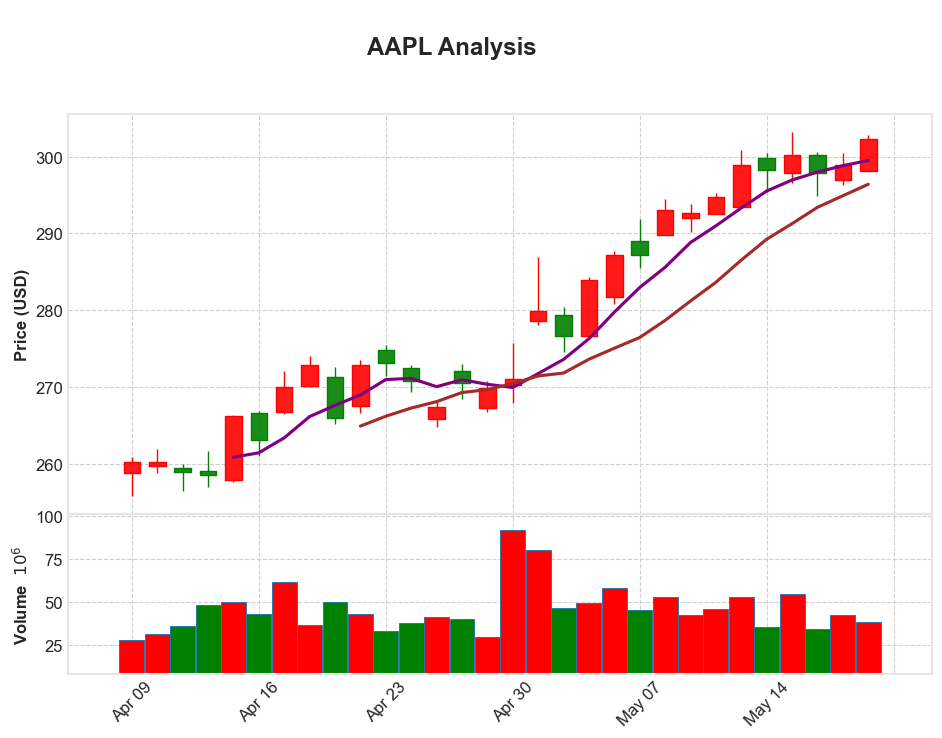

In [4]:
import yfinance as yf
import mplfinance as mpf
import pandas as pd

ticker = 'AAPL'
# tickers = ['AAPL', 'SPY', 'TSLA']
# 下载数据时直接禁用多级索引
df = yf.download(ticker, period='60d', progress=False, multi_level_index=False)
print(f'原始数据是：\n {df.tail(20)}')

if isinstance(df.columns, pd.MultiIndex):
    # 找到包含 'Open', 'High' 等关键词的那一层级
    df.columns = df.columns.get_level_values(0 if 'Open' in df.columns.get_level_values(0) else 1)
# get_level_values(level) 可以取出 MultiIndex 中指定 层级 的所有标签（返回一个普通的 Index 对象）。
# df.columns 被替换为单一层级的索引（原来 MultiIndex 中的某一级）。这里是0级

print("当前列名:", df.columns.tolist())

# 确保索引是日期格式（mplfinance 的硬性要求）
df.index = pd.to_datetime(df.index)
print('当前索引：',df.index)

df_plot = df.tail(30) #娶30个交易日数据，用于绘制近期K线图

# （红涨绿跌）
mc = mpf.make_marketcolors(up='red', down='green', edge='inherit', wick='inherit', volume='inherit')#默认是美股习惯（绿涨红跌），这里特意反转成中国/部分国际习惯的“红涨绿跌”
my_style = mpf.make_mpf_style(base_mpf_style='binance', marketcolors=mc,mavcolors=['#800080', '#A52A2A'])
#base_mpf_style='binance'：以 mplfinance 内置的 binance 风格（深色背景、网格线等）为基础。
#marketcolors=mc：将上面自定义的涨跌颜色应用到该风格中。
#设置5日、10日均线的颜色为紫色（#800080）和棕色（#A52A2A）
mpf.plot(df_plot, 
         type='candle',  #绘制蜡烛图（K 线）
         style=my_style,
         title=f'\n{ticker} Analysis',
         ylabel='Price (USD)',
         volume=True,  #在底部子图中显示成交量柱状图
         mav=(5, 10),  #叠加移动平均线：5 日均线和 10 日均线（单位：交易日）
         figsize=(12, 8))

## 3. 订单类型

### 为什么下单方式很重要？

想象你在农贸市场买苹果：
- **市价单（Market Order）**：「老板，给我来一斤，你说多少钱就多少钱！」——保证买到，但价格未知（在流动性差的市场里可能多付很多）
- **限价单（Limit Order）**：「老板，苹果 3.5 元/斤我就买，贵了我不买」——价格有保障，但可能买不到（价格没跌到那里）
- **止损单（Stop Order）**：「如果苹果跌到 3 元以下，我就赶快买！」（或做空时：「如果涨到 10 元以上，我就赶快割肉！」）

| 订单类型 | 通俗理解 | 优点 | 缺点 |
|----------|---------|------|------|
| **市价单 (Market Order)** | 「立刻成交，价格随便」 | 保证成交，速度最快 | 价格不可控，高波动时滑点大 |
| **限价单 (Limit Order)** | 「这个价格成交，否则不买」 | 控制价格，不会多付 | 可能等不到，错过交易机会 |
| **止损单 (Stop Order)** | 「跌破某价格就触发，马上卖」 | 自动保护，控制最大损失 | 触发后变市价单，极端行情滑点大 |
| **止损限价单** | 止损触发后变限价单 | 结合两者 | 极端行情可能根本无法成交 |

> **量化交易的实践：** 回测时通常用收盘价成交（理想化），实盘时要考虑滑点（Slippage），实际成交价会比预想的差一点。

## 4. 交易成本的影响

### 为什么策略在回测好，实盘就差？

这是量化新手最常见的坑：忘记算交易成本。

每次买卖，你都要付：
- **手续费（Commission）**：券商收的佣金，美股约 0.03%~0.1%/笔，A 股约 0.03%~0.3%
- **滑点（Slippage）**：你想按 100 元买，实际成交了 100.05 元（买卖价差）
- **冲击成本（Market Impact）**：大单买入会把价格推高

**一笔 0.2% 的成本，交易 200 次就是 40% 的成本。** 收益率本来 50%，扣完成本就剩 10% 了……

下面的模拟让你直观看到：同样一个有盈利能力的策略（55% 胜率），不同手续费吃掉多少利润：

效果是：
[ 0.01 -0.01 -0.01 -0.01  0.01  0.01  0.01 -0.01 -0.01 -0.01  0.01 -0.01
 -0.01  0.01  0.01  0.01  0.01 -0.01  0.01  0.01 -0.01  0.01  0.01  0.01
  0.01 -0.01  0.01 -0.01 -0.01  0.01 -0.01  0.01  0.01 -0.01 -0.01 -0.01
  0.01  0.01 -0.01  0.01  0.01  0.01  0.01 -0.01  0.01 -0.01  0.01 -0.01
 -0.01  0.01 -0.01 -0.01 -0.01 -0.01 -0.01 -0.01  0.01  0.01  0.01  0.01
  0.01  0.01 -0.01  0.01  0.01 -0.01  0.01 -0.01  0.01 -0.01 -0.01  0.01
  0.01 -0.01 -0.01 -0.01 -0.01  0.01  0.01  0.01 -0.01 -0.01  0.01  0.01
  0.01  0.01 -0.01 -0.01 -0.01  0.01  0.01 -0.01 -0.01 -0.01 -0.01  0.01
 -0.01  0.01  0.01  0.01  0.01 -0.01  0.01 -0.01 -0.01  0.01  0.01 -0.01
  0.01  0.01  0.01  0.01 -0.01 -0.01 -0.01 -0.01 -0.01  0.01 -0.01 -0.01
 -0.01 -0.01  0.01  0.01  0.01  0.01 -0.01 -0.01  0.01 -0.01  0.01  0.01
  0.01  0.01 -0.01  0.01 -0.01 -0.01  0.01 -0.01 -0.01  0.01  0.01  0.01
  0.01  0.01 -0.01 -0.01  0.01  0.01 -0.01  0.01  0.01  0.01 -0.01  0.01
 -0.01 -0.01  0.01 -0.01  0.01 -0.01 -0.01 -0.

/tmp/ipykernel_489/2061324446.py:36: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_489/2061324446.py:36: UserWarning: Glyph 26131 (\N{CJK UNIFIED IDEOGRAPH-6613}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_489/2061324446.py:36: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_489/2061324446.py:36: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_489/2061324446.py:36: UserWarning: Glyph 36164 (\N{CJK UNIFIED IDEOGRAPH-8D44}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_489/2061324446.py:36: UserWarning: Glyph 20135 (\N{CJK UNIFIED IDEOGRAPH-4EA7}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_489/2061324446.py:36: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Arial.
  plt.tight_l

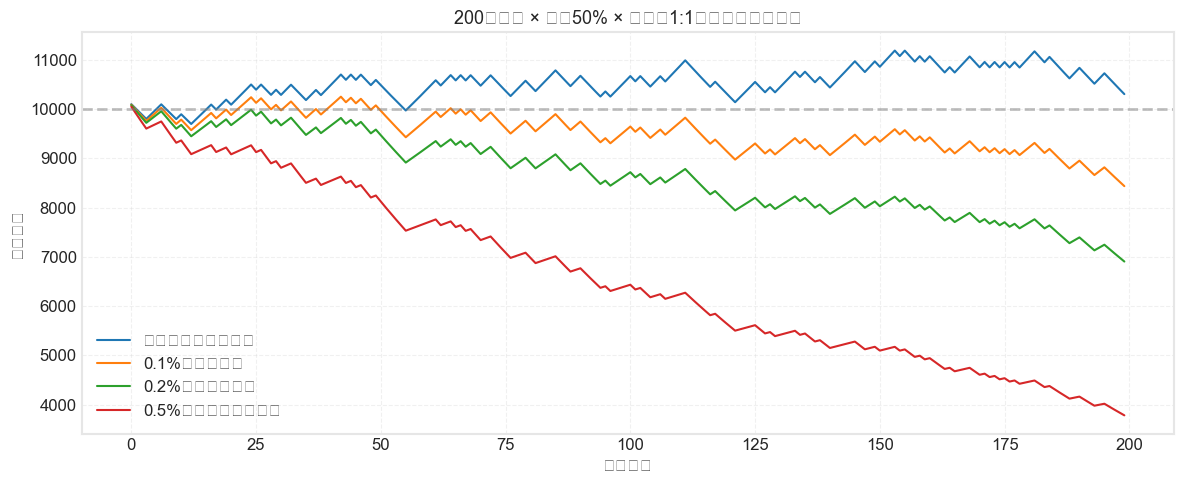

💡 结论：高频策略对手续费极其敏感；频率越高，成本的影响越大！
💡 量化回测时必须加入真实的手续费假设，否则回测结果毫无参考价值。


In [5]:
# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']
# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
# 模拟交易成本对策略的影响
np.random.seed(42)
n_trades = 200
# 假设每笔交易有 55% 的胜率，盈亏比 1:1，举例：如果你平均每笔赚 100 元，那么平均每笔也亏 100 元（不含手续费）。
win_rate = 0.5
win_amount = 0.01   # 每次盈利 1%
loss_amount = -0.01  # 每次亏损 1%

outcomes = np.random.choice([win_amount, loss_amount],  # 每次随机抽样的可能结果只有这两个值。[0.01, -0.01]
                              size=n_trades,   # 返回一个长度为 200 的一维数组
                            p=[win_rate, 1 - win_rate]) # 每次抽样，抽到 0.01 的概率是 55%，抽到 -0.01 的概率是 45%。
print(f'效果是：\n{outcomes}') # 注意：outcomes（效果）的值，每次运行，结果都是一样的，因为np.random.seed(42) 是定量随机数

# 不同手续费率
commission_rates = [0, 0.001, 0.002, 0.005]
labels = ['无成本（理想回测）', '0.1%（低佣金）', '0.2%（常见水平）', '0.5%（偏高，会亏钱）']

fig, ax = plt.subplots(figsize=(12, 5))
for rate, label in zip(commission_rates, labels): #zip 在这里的作用是将两个列表 commission_rates 和 labels 按照相同位置“打包”成一个个元组，
    #然后 for 循环每次从中取出一个元组，并自动解包给变量 rate 和 label。
    net = outcomes - rate  # 每笔扣除手续费，net 是扣除手续费后的净收益率
    cum = (1 + net).cumprod() * 10000 #计算考虑交易成本后的账户资金曲线，初始资金为 10000 元，.cumprod()累积乘积
    ax.plot(cum, label=label, linewidth=1.5)

ax.axhline(10000, color='gray', linestyle='--', alpha=0.5)#x轴的平行线，y值是10000
ax.set_title(f'200笔交易 × 胜率{win_rate:.0%} × 盈亏比1:1：交易成本的侵蚀', fontsize=13)
ax.set_xlabel('交易次数')
ax.set_ylabel('资产价值')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('💡 结论：高频策略对手续费极其敏感；频率越高，成本的影响越大！')
print('💡 量化回测时必须加入真实的手续费假设，否则回测结果毫无参考价值。')

## 🎯 练习

1. 观察 K 线图中的**长上影线**和**长下影线**分别意味着什么样的多空博弈？
2. 将上方模拟中 `win_rate` 改为 0.50（完全随机），观察不同手续费下的结果。在没有信息优势的情况下，手续费本身就决定了你一定会亏钱。
3. **思考**：如果一个策略每天交易 10 次，手续费 0.1%，需要多高的日胜率才能覆盖成本？（提示：每天成本 = 10 × 0.2% = 2%，每笔需要净盈利 0.2% 才能回本）

---
**下一模块** → `../02_data/01_data_sources.ipynb`